In [7]:
import numpy as np

DATA_PATH = r"D:\emotion-drift-project\datasets"

X = np.load(DATA_PATH + "\\X_train.npy")
y = np.load(DATA_PATH + "\\y_train.npy")
groups = np.load(DATA_PATH + "\\groups.npy")

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

X: (96342, 100, 38)
y: (96342,)
groups: (96342, 2)


In [8]:
if len(np.unique(groups)) < 2:
    print("⚠️ Fixing groups (fallback)")
    groups = np.array([i // 100 for i in range(len(X))])

In [9]:
# Ensure all have EXACT same length
min_len = min(len(X), len(y), len(groups))

X = X[:min_len]
y = y[:min_len]
groups = groups[:min_len]

print("Final aligned shapes:", X.shape, y.shape, groups.shape)

Final aligned shapes: (96342, 100, 38) (96342,) (96342, 2)


In [10]:
groups = np.array([i // 100 for i in range(len(X))])

In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [15]:
from sklearn.model_selection import GroupShuffleSplit

gss_val = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx2, val_idx = next(gss_val.split(X_train, y_train, groups_train))

X_train, X_val = X_train[train_idx2], X_train[val_idx]
y_train, y_val = y_train[train_idx2], y_train[val_idx]

NameError: name 'groups_train' is not defined

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential([

        # CNN Block 1
        layers.Conv1D(32, 3, activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.4),

        # CNN Block 2
        layers.Conv1D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.4),

        # LSTM
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),

        # Dense
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(len(np.unique(y)), activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.summary()

c:\Users\samik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 32)        │         3,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,508 (177.77 KB)

 Trainable params: 45,316 (177.02 KB)

 Non-trainable params: 192 (768.00 B)

NameError: name 'groups_train' is not defined

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,   # lower = safer for memory
    callbacks=callbacks,
    verbose=1
)

NameError: name 'X_val' is not defined

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Running GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 200}
Best CV accuracy: 0.791
Final test accuracy: 0.7000

Classification report:
               precision    recall  f1-score   support

        High       0.82      0.74      0.78        38
         Low       0.71      0.74      0.72        23
    Moderate       0.56      0.62      0.59        29

    accuracy                           0.70        90
   macro avg       0.70      0.70      0.70        90
weighted avg       0.71      0.70      0.70        90



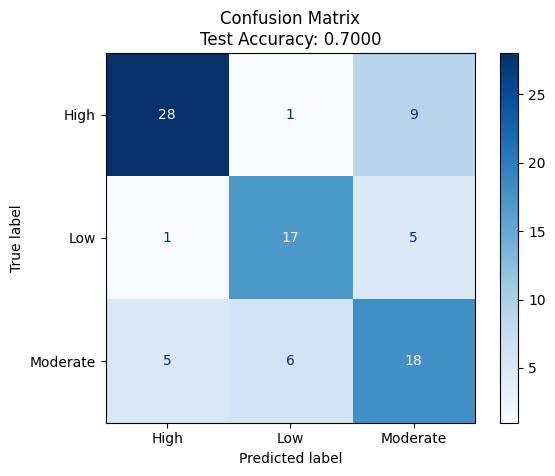

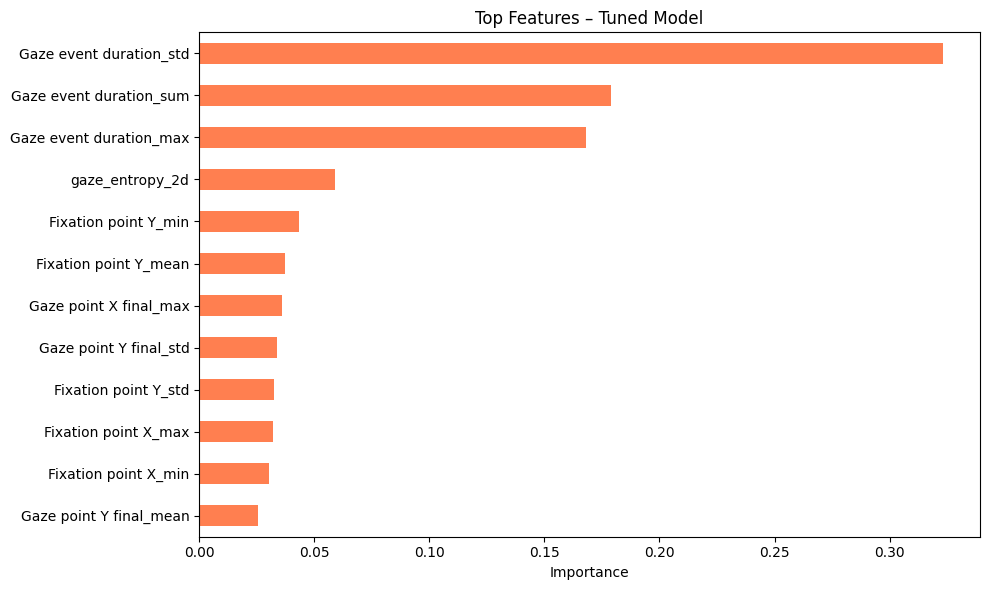

In [ ]:
model.save("eye_emotion_final.h5")

In [16]:
# Cell 8 – Save best model & results

joblib.dump(best_rf, MODEL_SAVE)
print(f"Best model saved: {MODEL_SAVE}")

# Optional: save predictions
results = pd.DataFrame({
    'true': y_test,
    'predicted': y_pred_best
})
results.to_csv(r"D:\emotion-drift-project\data\test_predictions.csv", index=False)
print("Test predictions saved.")

Best model saved: D:\emotion-drift-project\data\rf_model_best.joblib
Test predictions saved.


In [17]:
# Quick re-run with slightly deeper trees

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv_scores_final = cross_val_score(
    rf_final,
    X_train_red,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"Updated CV accuracy: {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}")

Updated CV accuracy: 0.7762 ± 0.0612


In [19]:
import pandas as pd
import numpy as np
import joblib
from scipy.spatial.distance import pdist
from scipy.stats import entropy
MODEL_PATH = r"D:\emotion-drift-project\data\rf_model_best.joblib"
model = joblib.load(MODEL_PATH)
print("Model loaded successfully!\n")
sample_data = pd.DataFrame({
    'Gaze point X final': [500, 501, 499, 500, 502, 498, 500],
    'Gaze point Y final': [400, 399, 401, 400, 398, 402, 400],
    'Gaze event duration': [320, 340, 330, 310, 350, 325, 315]
})
print("Sample trial data:")
print(sample_data)
features = {}
features['Gaze point X final_mean'] = sample_data['Gaze point X final'].mean()
features['Gaze point X final_std']  = sample_data['Gaze point X final'].std()
features['Gaze point Y final_mean'] = sample_data['Gaze point Y final'].mean()
features['Gaze point Y final_std']  = sample_data['Gaze point Y final'].std()

features['Gaze event duration_mean'] = sample_data['Gaze event duration'].mean()
features['Gaze event duration_std']  = sample_data['Gaze event duration'].std()
features['Gaze event duration_sum']  = sample_data['Gaze event duration'].sum()
features['Gaze event duration_max']  = sample_data['Gaze event duration'].max()

coords = sample_data[['Gaze point X final', 'Gaze point Y final']]
features['gaze_dispersion_mean'] = pdist(coords).mean()

hist, _, _ = np.histogram2d(
    sample_data['Gaze point X final'],
    sample_data['Gaze point Y final'],
    bins=10
)
hist = hist / hist.sum()
features['gaze_entropy_2d'] = entropy(hist.flatten() + 1e-10)

features_df = pd.DataFrame([features])

print("\nCalculated features:")
print(features_df)

if hasattr(model, 'feature_names_in_'):
    expected_features = list(model.feature_names_in_)
else:
    expected_features = features_df.columns.tolist()

for f in expected_features:
    if f not in features_df.columns:
        features_df[f] = 0.0

features_df = features_df[expected_features]

features_df = features_df.apply(pd.to_numeric, errors='coerce').fillna(0.0)

print("\nAligned feature vector:")
print(features_df)

prediction = model.predict(features_df)[0]

print("\nPredicted Gaze Behavior Level:")
print("Predicted Output:", prediction)

Model loaded successfully!

Sample trial data:
   Gaze point X final  Gaze point Y final  Gaze event duration
0                 500                 400                  320
1                 501                 399                  340
2                 499                 401                  330
3                 500                 400                  310
4                 502                 398                  350
5                 498                 402                  325
6                 500                 400                  315

Calculated features:
   Gaze point X final_mean  Gaze point X final_std  Gaze point Y final_mean  \
0                    500.0                1.290994                    400.0   

   Gaze point Y final_std  Gaze event duration_mean  Gaze event duration_std  \
0                1.290994                327.142857                14.099983   

   Gaze event duration_sum  Gaze event duration_max  gaze_dispersion_mean  \
0                     2290    

In [3]:
print("Total samples:", len(groups))
print("Unique groups:", len(np.unique(groups)))
print(np.unique(groups)[:10])

Total samples: 96342
Unique groups: 1
['Participant name']
